# 01. Предобработка данных о продажах (`check.csv`)

**Цель ноутбука** — получить подготовленный датасет, который можно затем переиспользовать в аналитических отчётах.

**Главное, что мы найдём (вывод сверху, как в отчёте):**

1. `TERRITORY = "NA"` — это **North America**, а pandas по умолчанию читает строку `"NA"` как пропуск. Без правильной загрузки теряется регион с ~38% строк.
2. `ORDERDATE` записана в **двух форматах вперемешку**: ~41% дат — `день/месяц/год`, остальные — `месяц/день/год`. Автоматический парсинг молча переставляет день и месяц.
3. `PRICEEACH` **обрезана сверху значением 100** почти в половине строк. Это не выброс, а цензурирование: реальная цена выше. Значит, расчётные продажи `QUANTITYORDERED × PRICEEACH` — это **нижняя оценка**.
4. Большие значения `QUANTITYORDERED` (до 97 шт.) — не ошибки, а реальные крупные заказы. Удалять их не нужно.

In [1]:
import style
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook", palette=style.CATEGORY_PALETTE)
style.apply_default_style()
pd.set_option("display.max_columns", 30)

DATA_PATH = Path("data")

RAW_PATH = DATA_PATH / "check.csv"
OUT_PKL = DATA_PATH / "sales_clean.pkl"
OUT_CSV = DATA_PATH / "sales_clean.csv"

## 1. Наивная загрузка

Сначала загрузим файл «как все» — одной строкой — и посмотрим, какие проблемы это создаёт.

In [2]:
df_naive = pd.read_csv(RAW_PATH, parse_dates=["ORDERDATE"])

print("Размер:", df_naive.shape)
print()
print(df_naive.dtypes.value_counts())
df_naive[["ORDERNUMBER", "QUANTITYORDERED", "ORDERDATE", "TERRITORY"]].head()

Размер: (2832, 22)

str               14
float64            7
datetime64[us]     1
Name: count, dtype: int64


,ORDERNUMBER,QUANTITYORDERED,ORDERDATE,TERRITORY
0,10107.0,30.0,2003-02-24,NaN
1,10121.0,34.0,2003-07-05,EMEA
2,10134.0,41.0,2003-01-07,EMEA
3,10145.0,45.0,2003-08-25,NaN
4,10159.0,49.0,2003-10-10,NaN


In [3]:
# Проблема 1: целочисленные поля стали float — значит, в них есть пропуски
print("ORDERNUMBER:", df_naive["ORDERNUMBER"].dtype)

# Проблема 2: TERRITORY — сравним наивную загрузку и чтение «как текст»
territory_as_text = pd.read_csv(RAW_PATH, usecols=["TERRITORY"], dtype="string",
                                keep_default_na=False)["TERRITORY"]
print(df_naive["TERRITORY"].value_counts(dropna=False))
print(territory_as_text.value_counts())

ORDERNUMBER: float64
TERRITORY
EMEA     1407
NaN      1083
APAC      221
Japan     121
Name: count, dtype: int64
TERRITORY
EMEA     1407
NA       1074
APAC      221
Japan     121
            9
Name: count, dtype: Int64


**Что видим:**

- В наивной загрузке у `TERRITORY` больше 1000 «пропусков», а при чтении как текст — значение `NA`.
  В этом датасете `NA` — это **North America** (США и Канада). pandas по умолчанию считает строки `"NA"`, `"N/A"`, `"null"` и т.п. пропусками (`keep_default_na=True`).
- Пустая строка (`''`) в `TERRITORY` — это полностью пустые строки файла, к ним вернёмся ниже.

## 2. Правильная загрузка

Что задаём в `pd.read_csv`:

| Аргумент | Зачем |
|---|---|
| `keep_default_na=False, na_values=[""]` | пропуском считаем **только** пустую ячейку, `"NA"` остаётся регионом |
| `dtype` | целые — `Int64`, категории — `category`, текст — `string` |
| `DEALSIZE` → упорядоченная категория | `Small < Medium < Large`: графики и сортировки будут в правильном порядке |
| `ORDERDATE` — **пока строка** | формат дат смешанный, `parse_dates` здесь опасен (см. раздел 3) |

TERRITORY: {'EMEA': 1407, 'NA': 1074, 'APAC': 221, 'Japan': 121, nan: 9}


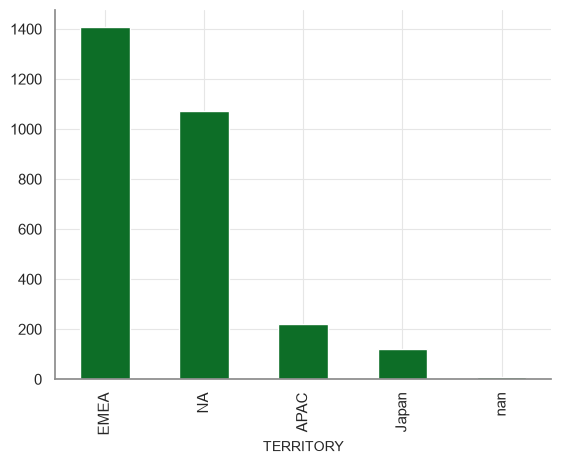

In [4]:
DEAL_ORDER = pd.CategoricalDtype(["Small", "Medium", "Large"], ordered=True)

DTYPES = {
    # идентификаторы и счётчики — целые числа
    "ORDERNUMBER": "Int64", 
    "QUANTITYORDERED": "Int64", 
    "ORDERLINENUMBER": "Int64",
    "QTR_ID": "Int64", 
    "MONTH_ID": "Int64",
    "YEAR_ID": "Int64",
    "PRICEEACH": "float64",
    # мало уникальных значений — категории
    "STATUS": "category", 
    "PRODUCTLINE": "category", 
    "COUNTRY": "category",
    "TERRITORY": "category", 
    "DEALSIZE": DEAL_ORDER,
    # текст (почтовый индекс — тоже текст: 'N 5804', ведущие нули)
    "ORDERDATE": "string", 
    "PRODUCTCODE": "string", 
    "CUSTOMERNAME": "string",
    "ADDRESSLINE1": "string",
    "ADDRESSLINE2": "string", 
    "CITY": "string",
    "STATE": "string", 
    "POSTALCODE": "string",
    "CONTACTLASTNAME": "string", 
    "CONTACTFIRSTNAME": "string"
}

df = pd.read_csv(
    RAW_PATH,
    dtype=DTYPES,
    keep_default_na=False,
    na_values=[""],
    encoding="utf-8-sig",
)

print("TERRITORY:", df["TERRITORY"].value_counts(dropna=False).to_dict())
df['TERRITORY'].value_counts(dropna=False).plot.bar(color=style.GREEN_DARK);

## 3. Даты: смешанный формат

В данных есть «контрольные» поля `MONTH_ID`, `QTR_ID`, `YEAR_ID`. Используем их, чтобы **проверить** парсинг даты.
Сравним месяц из наивно распарсенной даты с `MONTH_ID`.

In [5]:
naive_month = df_naive["ORDERDATE"].dt.month
mismatch = naive_month.notna() & (naive_month != df_naive["MONTH_ID"])

print(f"Строк, где месяц даты ≠ MONTH_ID: {mismatch.sum()} ({mismatch.mean():.1%})")
df_naive.loc[mismatch, ["ORDERDATE", "MONTH_ID", "QTR_ID"]].head(6)

Строк, где месяц даты ≠ MONTH_ID: 1170 (41.3%)


,ORDERDATE,MONTH_ID,QTR_ID
1,2003-07-05,5.0,2.0
2,2003-01-07,7.0,3.0
8,2003-01-12,12.0,4.0
12,2004-05-04,4.0,2.0
19,2004-02-11,11.0,4.0
23,2005-03-02,2.0,1.0


In [6]:
def parse_order_date(data: pd.DataFrame, date_col="ORDERDATE",
                     month_col="MONTH_ID", qtr_col="QTR_ID", year_col="YEAR_ID"):
    """Для каждой строки выбирает формат даты, согласованный с MONTH_ID, QTR_ID и YEAR_ID.

    Возвращает (даты, использованный формат). Строки, где ни один формат не подошёл, получают NaT.
    """
    DATE_FORMATS = {"d/m/Y": "%d/%m/%Y %H:%M", "m/d/Y": "%m/%d/%Y %H:%M"}
    result = pd.Series(pd.NaT, index=data.index, dtype="datetime64[ns]")
    used_format = pd.Series(pd.NA, index=data.index, dtype="string")

    for name, fmt in DATE_FORMATS.items():
        parsed = pd.to_datetime(data[date_col], format=fmt, errors="coerce")
        consistent = (parsed.dt.month.eq(data[month_col])
                      & parsed.dt.quarter.eq(data[qtr_col])
                      & parsed.dt.year.eq(data[year_col])).fillna(False).astype(bool)
        take = consistent & result.isna()
        result[take] = parsed[take]
        used_format[take] = name

    return result, used_format

In [7]:
df["ORDERDATE"] = parse_order_date(df)[0]

assert (df["ORDERDATE"].dt.month == df["MONTH_ID"]).all()
assert (df["ORDERDATE"].dt.quarter == df["QTR_ID"]).all()
assert (df["ORDERDATE"].dt.year == df["YEAR_ID"]).all()

Насколько это важно для анализа? Сравним число строк заказов по месяцам при наивном и правильном парсинге.

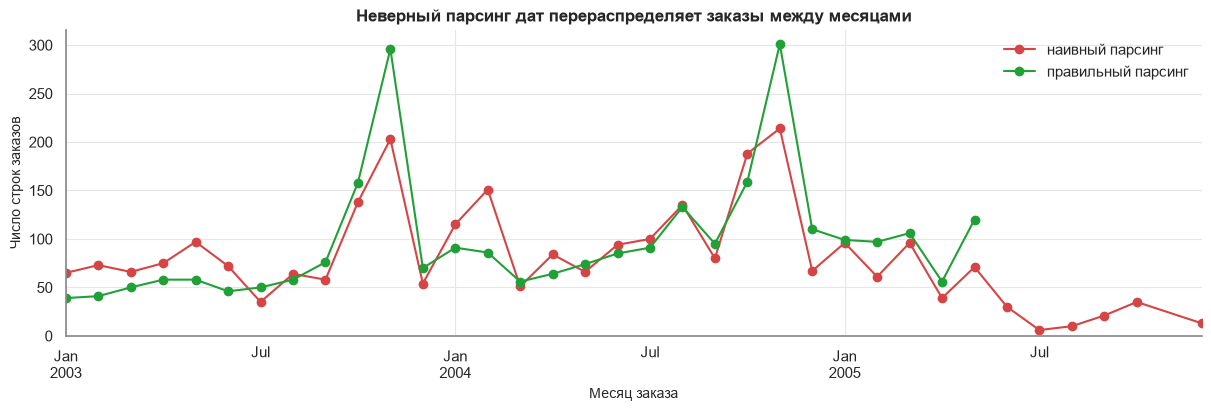

In [8]:
fig, ax = plt.subplots(figsize=(12, 4), layout="constrained")
for series, label, color in [
    (df_naive["ORDERDATE"], "наивный парсинг", style.ERROR_RED), 
    (df["ORDERDATE"], "правильный парсинг", style.GREEN)
]:
    series.dt.to_period("M").value_counts().sort_index().plot(
        ax=ax, marker="o", label=label, color=color
    )
ax.set_title("Неверный парсинг дат перераспределяет заказы между месяцами")
ax.set_xlabel("Месяц заказа")
ax.set_ylabel("Число строк заказов")
ax.set_ylim(0, None)
ax.legend()
plt.show()

**Вывод:** при наивном парсинге ноябрьские пики «размазываются» по другим месяцам.

## 4. Полностью пустые строки

In [9]:
empty_rows = df.isna().all(axis=1)
print("Полностью пустых строк:", empty_rows.sum())

df = df.loc[~empty_rows].reset_index(drop=True)

int_cols = ["ORDERNUMBER", "QUANTITYORDERED", "ORDERLINENUMBER", "QTR_ID", "MONTH_ID", "YEAR_ID"]
df[int_cols] = df[int_cols].astype("int64")
print("Размер после удаления:", df.shape)

Полностью пустых строк: 9
Размер после удаления: (2823, 22)


## 5. Заполнение пропусков

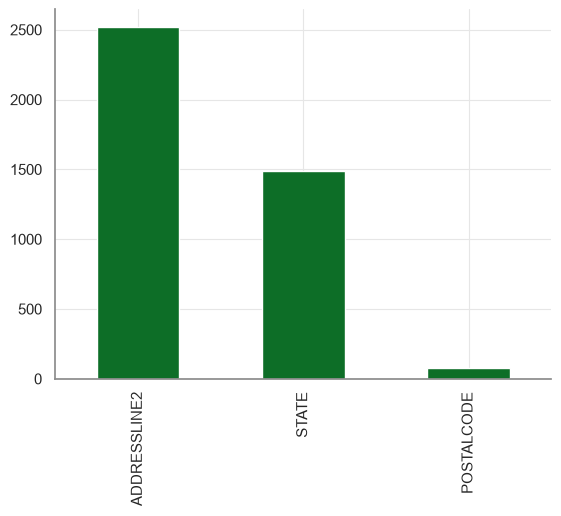

In [10]:
missing = df.isna().sum()
missing = missing[missing > 0].plot.bar(color=style.GREEN_DARK);

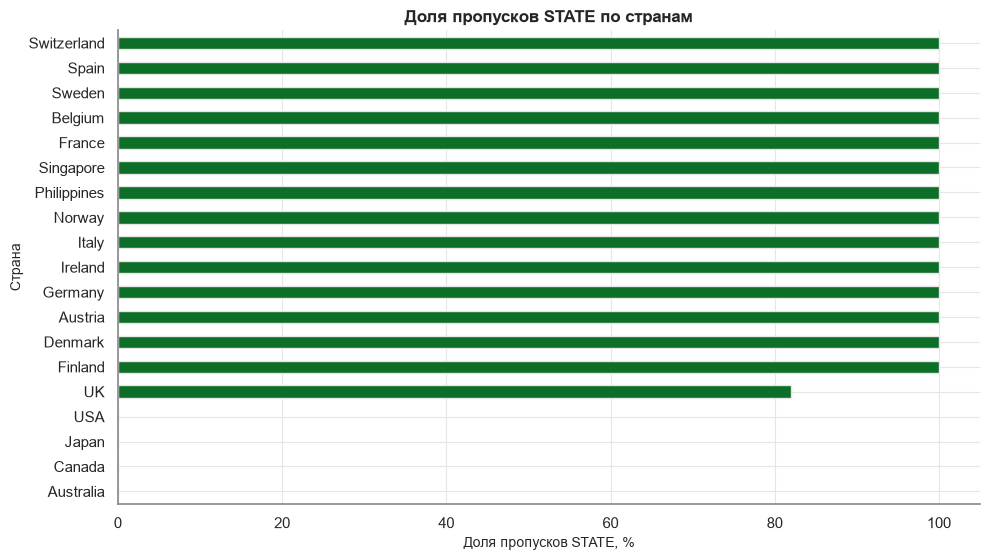

In [11]:
state_by_country = df.assign(
        STATE_MISSING=df["STATE"].isna()
).groupby("COUNTRY", observed=True)["STATE_MISSING"].mean().sort_values() * 100

state_by_country.plot.barh(
    figsize=(10, max(4, len(state_by_country) * 0.3)),
    color=style.GREEN_DARK,
    edgecolor=style.GRAY_LIGHT
)
plt.xlabel("Доля пропусков STATE, %")
plt.ylabel("Страна")
plt.title("Доля пропусков STATE по странам")
plt.tight_layout()
plt.show()

In [12]:
# Где пропущен POSTALCODE?
postal_code_nan_vc = df.loc[
    df["POSTALCODE"].isna(), 
    ["CUSTOMERNAME", "CITY", "COUNTRY",  "ADDRESSLINE1", "STATE"]
].value_counts()
postal_code_nan_vc[postal_code_nan_vc > 0]

CUSTOMERNAME                CITY           COUNTRY  ADDRESSLINE1               STATE
Corporate Gift Ideas Co.    San Francisco  USA      7734 Strong St.            CA       41
Mini Wheels Co.             San Francisco  USA      5557 North Pendale Street  CA       21
Men 'R' US Retailers, Ltd.  Los Angeles    USA      6047 Douglas Av.           CA       14
Name: count, dtype: int64

**Решения:**

| Столбец | Почему пропуск | Что делаем |
|---|---|---|
| `ADDRESSLINE2` | вторая строка адреса необязательна | `""` (пустая строка), это не ошибка |
| `STATE` | в большинстве стран Европы и Азии штатов нет | `"Not applicable"` — явная метка, что поле неприменимо |
| `POSTALCODE` | не указан у 3 клиентов из США, у каждого — во всех заказах, а также в Великобритании (у британского клиента указано графство Isle of Wight — это необязательная часть адреса) | `"Unknown"`: индекс нельзя вычислить из данных, выдумывать нельзя |

Заполнение средним/модой здесь было бы ошибкой: адрес клиента — это факт, а не статистика.

In [13]:
df["ADDRESSLINE2"] = df["ADDRESSLINE2"].fillna("")
df["STATE"] = df["STATE"].fillna("Not applicable")
df["POSTALCODE"] = df["POSTALCODE"].fillna("Unknown")

assert df.isna().sum().sum() == 0
print("Пропусков не осталось")

Пропусков не осталось


## 6. Очистка: согласованность и дубликаты

Проверяем некоторые правила:

In [14]:
checks = {
    "полных дубликатов строк": df.duplicated().sum(),
    "QTR_ID не соответствует MONTH_ID": ((df["MONTH_ID"] - 1) // 3 + 1 != df["QTR_ID"]).sum(),
}
pd.Series(checks, name="наблюдений").to_frame()

,наблюдений
полных дубликатов строк,0
QTR_ID не соответствует MONTH_ID,0


Теперь посмотрим на значения текстовых категорий.

In [15]:
df[["TERRITORY", "COUNTRY", "CITY"]].drop_duplicates().sort_values(by='CITY').values.tolist()

[['EMEA', 'Denmark', 'Aaarhus'],
 ['NA', 'USA', 'Allentown'],
 ['EMEA', 'Spain', 'Barcelona'],
 ['EMEA', 'Italy', 'Bergamo'],
 ['EMEA', 'Norway', 'Bergen'],
 ['EMEA', 'Sweden', 'Boras'],
 ['NA', 'USA', 'Boston'],
 ['NA', 'USA', 'Brickhaven'],
 ['NA', 'USA', 'Bridgewater'],
 ['NA', 'USA', 'Brisbane'],
 ['EMEA', 'Belgium', 'Bruxelles'],
 ['NA', 'USA', 'Burbank'],
 ['NA', 'USA', 'Burlingame'],
 ['NA', 'USA', 'Cambridge'],
 ['EMEA', 'Belgium', 'Charleroi'],
 ['APAC', 'Australia', 'Chatswood'],
 ['EMEA', 'UK', 'Cowes'],
 ['EMEA', 'Ireland', 'Dublin'],
 ['EMEA', 'Finland', 'Espoo'],
 ['EMEA', 'Germany', 'Frankfurt'],
 ['EMEA', 'Switzerland', 'Gensve'],
 ['APAC', 'Australia', 'Glen Waverly'],
 ['NA', 'USA', 'Glendale'],
 ['EMEA', 'Austria', 'Graz'],
 ['EMEA', 'Finland', 'Helsinki'],
 ['EMEA', 'Denmark', 'Kobenhavn'],
 ['EMEA', 'Germany', 'Koln'],
 ['NA', 'USA', 'Las Vegas'],
 ['EMEA', 'France', 'Lille'],
 ['EMEA', 'UK', 'Liverpool'],
 ['EMEA', 'UK', 'London'],
 ['NA', 'USA', 'Los Angeles'],
 

`NYC` записан сокращением, в отличие от остальных городов. Исправим словарём — так правка остаётся явной и воспроизводимой.

Ещё одно наблюдение: у Сингапура два разных `TERRITORY` (`Japan` и `APAC`), а Филиппины отнесены к `Japan`. Это скорее всего **назначение территорий продаж** в компании, а не география, поэтому данные не меняем, но помним об этом при анализе регионов.

In [16]:
CITY_FIX = {"NYC": "New York"}
df["CITY"] = df["CITY"].replace(CITY_FIX)

## 7. Невалидные данные

Смотрим на два ключевых числовых признака: количество и цену.

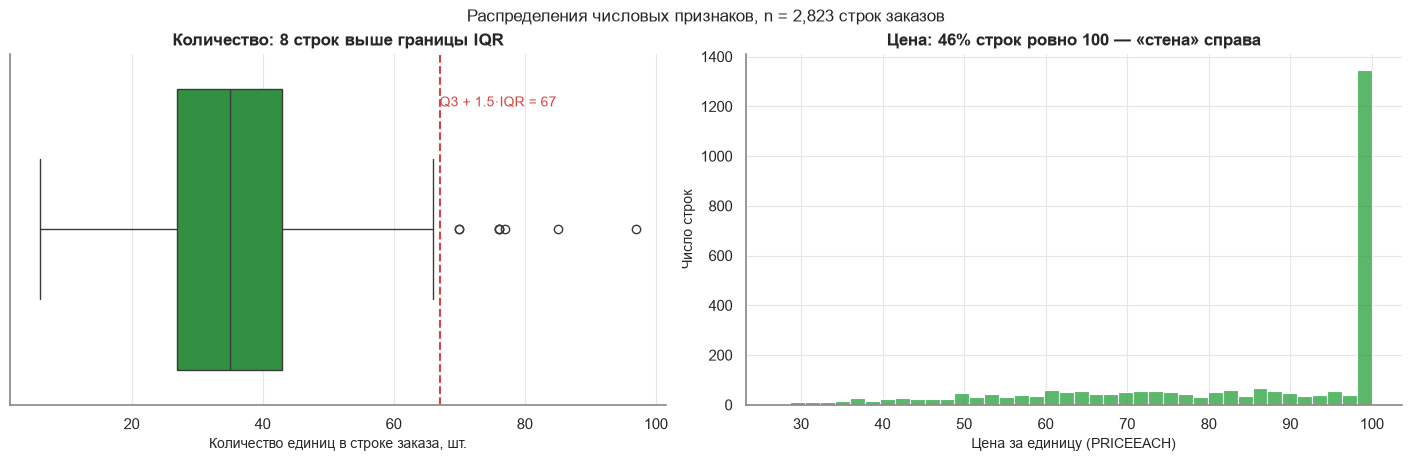

In [17]:
q = df["QUANTITYORDERED"]
q1, q3 = q.quantile([0.25, 0.75])
upper_iqr = q3 + 1.5 * (q3 - q1)
price_capped_share = (df["PRICEEACH"] == 100).mean()

fig, axes = plt.subplots(
    1, 2, figsize=(14, 4.5), 
    layout="constrained"
)

sns.boxplot(x=q, ax=axes[0], color=style.GREEN)
axes[0].axvline(upper_iqr, color=style.ERROR_RED, ls="--")
axes[0].annotate(f"Q3 + 1.5·IQR = {upper_iqr:.0f}", xy=(upper_iqr, -0.35), color=style.ERROR_RED)
axes[0].set_title(f"Количество: {(q > upper_iqr).sum()} строк выше границы IQR")
axes[0].set_xlabel("Количество единиц в строке заказа, шт.")

sns.histplot(df["PRICEEACH"], bins=40, ax=axes[1], color=style.GREEN)
axes[1].set_title(f"Цена: {price_capped_share:.0%} строк ровно 100 — «стена» справа")
axes[1].set_xlabel("Цена за единицу (PRICEEACH)")
axes[1].set_ylabel("Число строк")

fig.suptitle(f"Распределения числовых признаков, n = {len(df):,} строк заказов")
plt.show()

### 7.1. `QUANTITYORDERED`: крупные заказы — не ошибка

In [18]:
bulk = df.loc[q > upper_iqr, ["ORDERNUMBER", "ORDERDATE", "CUSTOMERNAME", "PRODUCTLINE",
                              "QUANTITYORDERED", "PRICEEACH", "STATUS"]]
print(df['ORDERDATE'].min(), df['ORDERDATE'].max())
bulk.sort_values("QUANTITYORDERED")

2003-01-06 00:00:00 2005-05-31 00:00:00


,ORDERNUMBER,ORDERDATE,CUSTOMERNAME,PRODUCTLINE,QUANTITYORDERED,PRICEEACH,STATUS
1666,10412,2005-05-03,Euro Shopping Channel,Trucks and Buses,70,100.00,Shipped
1996,10419,2005-05-17,Salzburg Collectables,Classic Cars,70,100.00,Shipped
1714,10407,2005-04-22,The Sharp Gifts Warehouse,Classic Cars,76,94.50,On Hold
598,10407,2005-04-22,The Sharp Gifts Warehouse,Vintage Cars,76,100.00,On Hold
1995,10405,2005-04-14,Mini Caravy,Classic Cars,76,100.00,Shipped
2689,10401,2005-04-03,Tekni Collectables Inc.,Planes,77,92.00,On Hold
2586,10401,2005-04-03,Tekni Collectables Inc.,Planes,85,88.75,On Hold
418,10405,2005-04-14,Mini Caravy,Classic Cars,97,93.28,Shipped


**Почему это не ошибки:** цены в этих строках обычные, клиенты — постоянные покупатели, значения целые и правдоподобные для оптовых заказов (70–97 шт.).
Зато видна закономерность: все они — **апрель–май 2005**, и половина строк — в статусе `On Hold`.
**Оставляем** и помечаем флагом `IS_BULK_LINE`.

### 7.2. `PRICEEACH`: «стена» на 100 — цензурирование

Почти половина цен равна ровно 100, а больше 100 нет ни одной. Похоже, что при выгрузке цену **обрезали сверху**.
Проверим это с помощью `DEALSIZE`: в исходной системе размер сделки считается по реальной сумме строки. Если восстановить пороги по строкам с «честной» ценной (< 100), они должны совпадать с `DEALSIZE`.

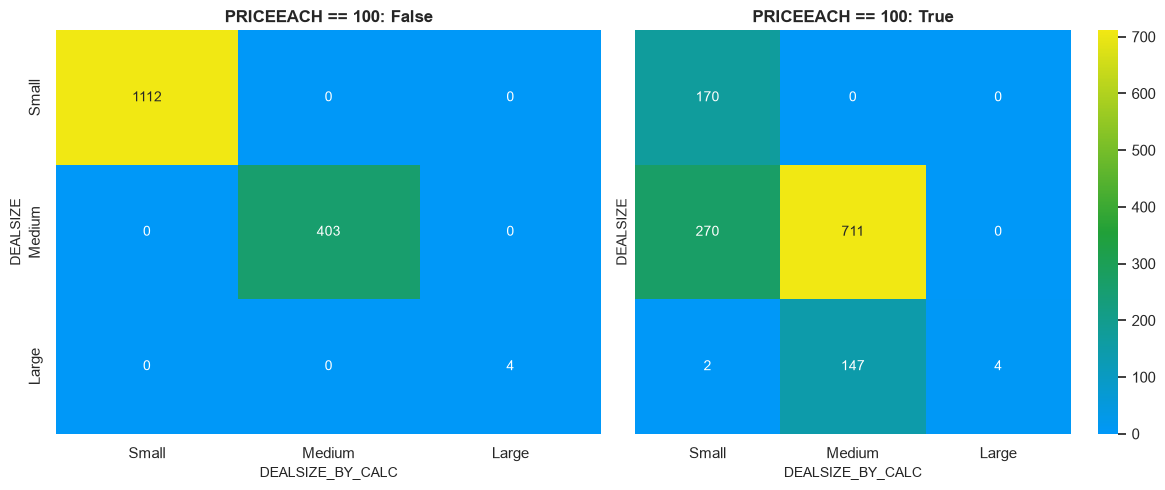

In [19]:
DEAL_SIZE_CUTS = [0, 3000, 7000]
DEAL_SIZE_CATEGORIES = ['Small', 'Medium', 'Large']



check = df.assign(
    SALES_CALC=df["QUANTITYORDERED"] * df["PRICEEACH"],
    PRICE_IS_100=df["PRICEEACH"] == 100,
)
check["DEALSIZE_BY_CALC"] = pd.cut(check["SALES_CALC"], bins=DEAL_SIZE_CUTS + [np.inf],
                                   labels=DEAL_ORDER.categories, right=False)

ct = pd.crosstab([check["PRICE_IS_100"], check["DEALSIZE"]], check["DEALSIZE_BY_CALC"])

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, flag in zip(axes, [False, True]):
    sub = ct.xs(flag, level="PRICE_IS_100")
    sns.heatmap(
        sub,
        annot=True, fmt="d",
        cmap=style.CMAP,
        cbar=(flag is True),
        ax=ax,
    )
    ax.set_title(f"PRICEEACH == 100: {flag}")
    ax.set_xlabel("DEALSIZE_BY_CALC")
    ax.set_ylabel("DEALSIZE")

plt.tight_layout()
plt.show()

**Результат однозначный:**

- в строках с ценой < 100 `DEALSIZE` **идеально** совпадает с порогами 3000 / 7000 от `количество × цена`;
- **все** расхождения — только в строках с ценой = 100: сделка по данным `Medium`/`Large`, а `количество × цена` даёт меньше. Значит, реальная цена там больше 100.

**Решение:**

- удалять или исправлять такие строки нельзя — это почти половина данных, и мы не знаем истинную цену;
- оставляем `PRICEEACH` как есть, добавляем флаг `PRICE_CAPPED`;
- расчётную выручку называем `SALES_EST` и везде помним, что это **нижняя оценка**, особенно для дорогих товаров.

## 8. Новые признаки

In [20]:
STATUS_GROUPS = {
    "Shipped": "Completed", 
    "Resolved": "Completed",
    "Cancelled": "Cancelled",
    "On Hold": "Problem", 
    "Disputed": "Problem",
    "In Process": "In progress", 
}
WEEKDAYS = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

df["SALES_EST"] = df["QUANTITYORDERED"] * df["PRICEEACH"]
df["PRICE_CAPPED"] = (df["PRICEEACH"] == 100)
df["IS_BULK_LINE"] = (df["QUANTITYORDERED"] > upper_iqr)

df["YEAR_MONTH"] = df["ORDERDATE"].dt.to_period("M").dt.to_timestamp()
df["WEEKDAY"] = pd.Categorical(df["ORDERDATE"].dt.day_name().str[:3], categories=WEEKDAYS, ordered=True)

df["STATUS_GROUP"] = pd.Categorical(
    df["STATUS"].astype("string").map(STATUS_GROUPS),
    categories=["Completed", "In progress", "Problem", "Cancelled"],
)

# признаки уровня заказа и клиента: transform возвращает значение для каждой строки
df["ORDER_LINES"] = df.groupby("ORDERNUMBER")["ORDERLINENUMBER"].transform("size")
df["ORDER_SALES_EST"] = df.groupby("ORDERNUMBER")["SALES_EST"].transform("sum")
df["CUSTOMER_ORDERS"] = df.groupby("CUSTOMERNAME")["ORDERNUMBER"].transform("nunique")

df[["ORDERNUMBER", "ORDERDATE", "SALES_EST", "PRICE_CAPPED", "STATUS_GROUP",
    "ORDER_LINES", "ORDER_SALES_EST", "CUSTOMER_ORDERS"]].head()

,ORDERNUMBER,ORDERDATE,SALES_EST,PRICE_CAPPED,STATUS_GROUP,ORDER_LINES,ORDER_SALES_EST,CUSTOMER_ORDERS
0,10107,2003-02-24,2871.00,False,Completed,8,21135.86,4
1,10121,2003-05-07,2765.90,False,Completed,5,15687.96,5
2,10134,2003-07-01,3884.34,False,Completed,7,20381.93,3
3,10145,2003-08-25,3746.70,False,Completed,16,47663.05,3
4,10159,2003-10-10,4900.00,True,Completed,18,48748.59,4


In [ ]:
DEAL_LOWER = {
    deal_cat: deal_val for 
    deal_cat, deal_val in zip(DEAL_SIZE_CATEGORIES, DEAL_SIZE_CUTS)
}
deal_lower = df["DEALSIZE"].map(DEAL_LOWER).astype(float)

df["PRICE_CAP_CONFIRMED"] = df["PRICE_CAPPED"] & (df["SALES_EST"] < deal_lower)
# нижняя граница выручки с учётом DEALSIZE
df["SALES_LB"] = np.maximum(df["SALES_EST"], deal_lower)

## 9. Cохранение датасета

In [23]:
df.to_pickle(OUT_PKL)
df.to_csv(OUT_CSV, index=False, date_format="%Y-%m-%d")
print(f"Сохранено: {OUT_PKL} и {OUT_CSV}, {df.shape[0]} строк × {df.shape[1]} столбцов")

Сохранено: data/sales_clean.pkl и data/sales_clean.csv, 2823 строк × 33 столбцов
